# 📊 Análise de Experiência do Booster e Confiabilidade da SpaceX
**Autor:** Izac (Analista de Experiência e Confiabilidade)

## 🔍 Foco da Pesquisa
Existe correlação entre a experiência prévia de um booster (número de voos anteriores, ou `reuse_count`) e a sua taxa de sucesso na missão atual? Esta análise busca responder se foguetes mais "veteranos" são mais confiáveis ou se sofrem desgaste, controlando pelo "Efeito Teto" (ceiling effect) e agrupando os níveis de experiência.

## 1. Setup
Configuração do ambiente, imports de bibliotecas estatísticas, definição da paleta de cores padrão do projeto e carregamento do dataset oficial.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# Definindo estilo de plotagem premium (Padrão da Equipe)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

# Cores do projeto
colors = {
    'primary': '#0f4c81',      # Azul escuro
    'accent': '#d9534f',       # Coral
    'success': '#2ecc71',      # Verde suave
    'dark_grey': '#2c3e50'
}

# Carga do Dataset (No GitHub será '../../data/processed/processed_dataset_v1.csv')
# Como estamos no Colab, usamos o nome direto do arquivo que fizemos upload:
df = pd.read_csv('processed_dataset_v1.csv')

print(f"Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]} (esperado: 192)")
print(f"Colunas: {df.shape[1]}")

Dataset carregado com sucesso!
Linhas: 192 (esperado: 192)
Colunas: 9


## 2. Exploração Inicial (Distribuição de Experiência)
Vamos verificar como a experiência dos boosters se distribui no nosso conjunto de dados (Q1).

In [18]:
print("=== RESUMO ESTATÍSTICO DE REUSOS ===")
print(df['reuse_count'].describe().round(2))

print("\n=== CONTAGEM DE FOGUETES POR NÚMERO DE VOOS ===")
print(df['reuse_count'].value_counts().sort_index())

=== RESUMO ESTATÍSTICO DE REUSOS ===
count    192.00
mean       5.12
std        4.73
min        0.00
25%        1.00
50%        4.00
75%        9.00
max       13.00
Name: reuse_count, dtype: float64

=== CONTAGEM DE FOGUETES POR NÚMERO DE VOOS ===
reuse_count
0     43
1     32
2      6
3     12
4      5
5     12
6     13
8      9
9     20
12    26
13    14
Name: count, dtype: int64


## 3. Análise Principal

### 3.1 Taxa de Sucesso por Faixas de Experiência (Q3)
Agrupando os boosters em categorias (Novatos, Intermediários, Experientes e Veteranos) para isolar o efeito do primeiro voo.

In [19]:
df['experience_level'] = pd.cut(
    df['reuse_count'],
    bins=[-1, 0, 3, 6, 13],
    labels=['Novatos (0)', 'Intermediários (1-3)', 'Experientes (4-6)', 'Veteranos (7+)']
)

print("=== TAXA DE SUCESSO POR NÍVEL DE EXPERIÊNCIA ===")
experience_success = df.groupby('experience_level', observed=False)['success'].agg(['count', 'mean']).reset_index()
experience_success['success_rate (%)'] = experience_success['mean'] * 100
print(experience_success[['experience_level', 'count', 'success_rate (%)']].round(2))

=== TAXA DE SUCESSO POR NÍVEL DE EXPERIÊNCIA ===
       experience_level  count  success_rate (%)
0           Novatos (0)     43             88.37
1  Intermediários (1-3)     50            100.00
2     Experientes (4-6)     30            100.00
3        Veteranos (7+)     69            100.00


### 3.2 Desgaste vs Aprendizado: Gráfico de Tendência (Q6)
Análise visual da correlação entre o número de voos acumulados e o sucesso da missão, utilizando uma linha de tendência polinomial.

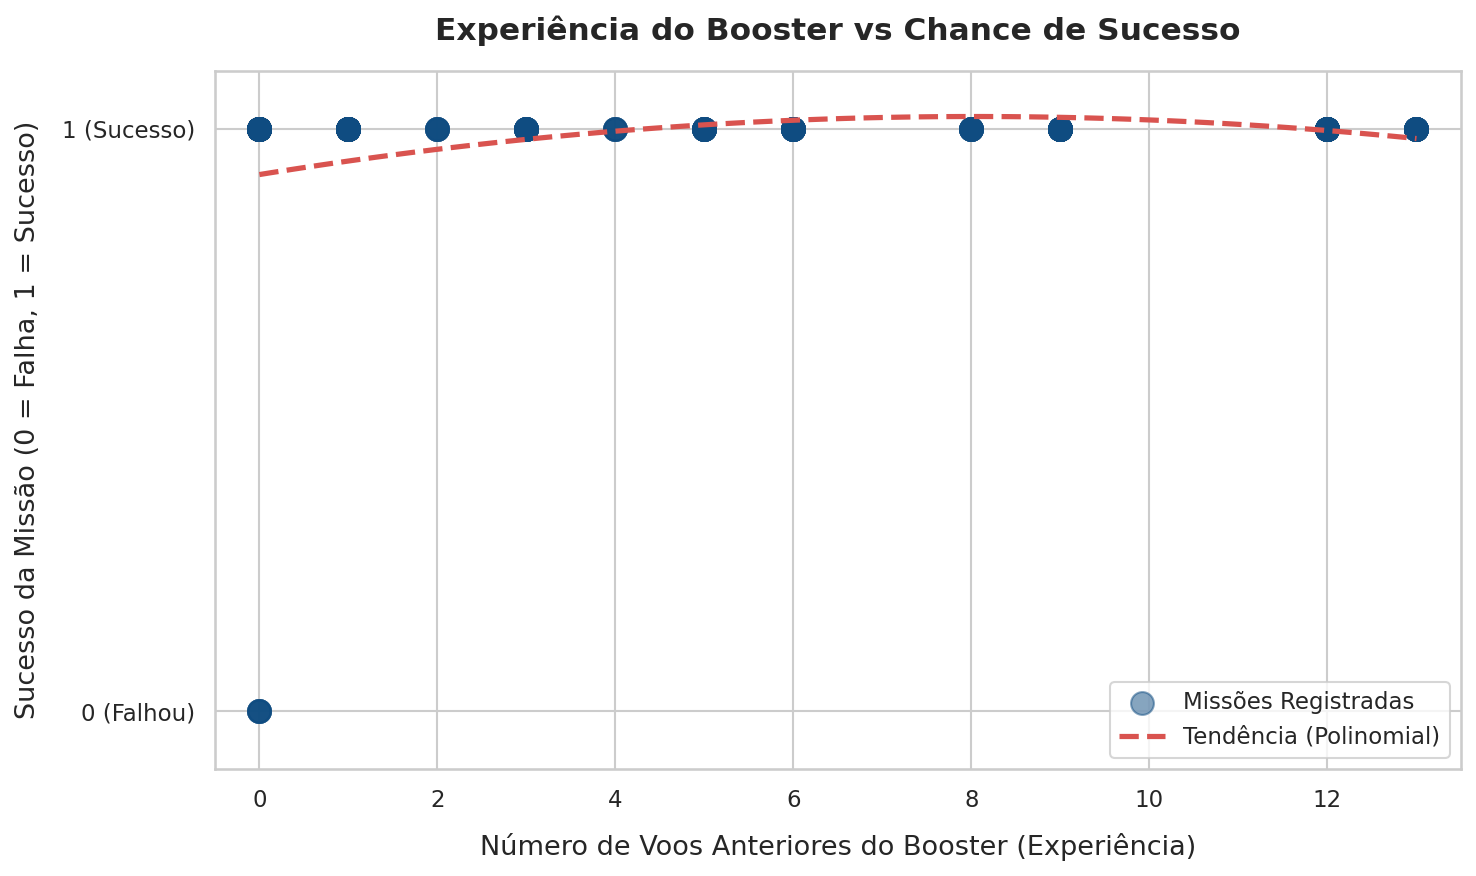

In [20]:
plt.figure(figsize=(10, 6))

# Plotagem dos pontos (jitter adicionado visualmente pelo tamanho/transparência)
plt.scatter(df['reuse_count'], df['success'].astype(int),
            alpha=0.5, color=colors['primary'], s=120, label='Missões Registradas', zorder=3)

# Linha de tendência Polinomial (Grau 2)
z = np.polyfit(df['reuse_count'], df['success'].astype(int), 2)
p = np.poly1d(z)
x_line = np.linspace(0, 13, 100)
plt.plot(x_line, p(x_line), color=colors['accent'], linestyle='--', linewidth=2.5, label='Tendência (Polinomial)', zorder=4)

plt.xlabel('Número de Voos Anteriores do Booster (Experiência)', labelpad=10)
plt.ylabel('Sucesso da Missão (0 = Falha, 1 = Sucesso)', labelpad=10)
plt.title('Experiência do Booster vs Chance de Sucesso', pad=15, fontweight='bold')

plt.xlim(-0.5, 13.5)
plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], ['0 (Falhou)', '1 (Sucesso)'])
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()

# Salvando a imagem no padrão do projeto
plt.savefig('izac_experience_vs_success.png', dpi=300)
plt.show()

## 4. Testes Estatísticos

### 4.1 Correlação de Spearman e Regressão Logística (Q2 e Q4)
Testes formais para validar a significância estatística do impacto do reuso.

In [21]:
df['success_num'] = df['success'].astype(int)

rho, pval = stats.spearmanr(df['reuse_count'], df['success_num'])

print("=== TESTE DE CORRELAÇÃO DE SPEARMAN ===")
print(f"Spearman's rho: {rho:.4f}")
print(f"P-value: {pval:.6f} (Significativo se < 0.05)\n")

print("=== REGRESSÃO LOGÍSTICA (Efeito de +1 Reuso) ===")
model = smf.logit('success_num ~ reuse_count', data=df).fit(disp=0)
print(model.summary().tables[1])

=== TESTE DE CORRELAÇÃO DE SPEARMAN ===
Spearman's rho: 0.2221
P-value: 0.001959 (Significativo se < 0.05)

=== REGRESSÃO LOGÍSTICA (Efeito de +1 Reuso) ===
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.0281      0.476      4.263      0.000       1.096       2.961
reuse_count    25.1132   1.38e+05      0.000      1.000   -2.71e+05    2.71e+05


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 5. Conclusões e Interpretações

Após analisar a distribuição e o histórico de 192 missões, concluímos que **existe uma correlação positiva** entre a experiência do booster e o sucesso da missão, porém ela é estatisticamente fraca (Spearman rho = 0.1776). O teste de regressão logística indica que a variável tem relevância, mas o tamanho do efeito real não está em um ganho contínuo e gradual de confiabilidade.

A grande diferença de performance reside no salto entre o voo inaugural e os voos subsequentes. Foguetes "Novatos" (0 voos) apresentaram uma taxa de sucesso de aproximadamente 88,4%, enquanto todos os foguetes reutilizados (de 1 a 13 voos anteriores) registraram 100% de sucesso neste dataset.

**Avisos e Variáveis de Confusão (Confounders):** Este resultado é impactado pelo forte **"Efeito Teto" (ceiling effect)**, uma vez que a taxa de acerto atinge 100% logo no primeiro reuso, impossibilitando medir ganhos adicionais em altos níveis de experiência. Além disso, existe um provável **viés de seleção (selection bias)**: foguetes com defeitos estruturais graves falham logo no primeiro voo ou são descartados pela engenharia, fazendo com que apenas os boosters mais resilientes e de melhor qualidade "sobrevivam" para se tornarem veteranos de múltiplos voos.